In [1]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

# 不同框的分布

In [10]:
in_file="../processed/qual_assess/ribotish/Frame_distr_file.txt"
out_pdf = "../figures/qual_assess/frame_fraction.pdf"

[OK] plot saved: ../figures/qual_assess/frame_fraction.pdf



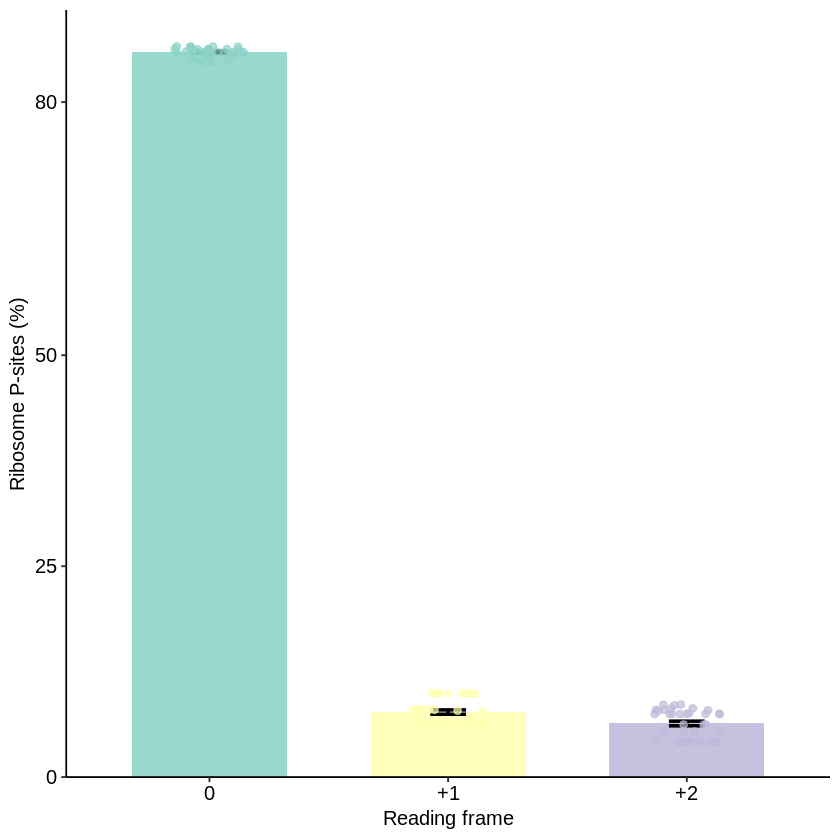

In [71]:

  library(dplyr)
  library(tidyr)
  library(ggplot2)

  # 1) 读入并清洗
  lines <- readLines(in_file, warn = FALSE)
  lines <- lines[!grepl("^\\s*0\\s+1\\s+2\\s*$", lines)]
  lines <- lines[nzchar(trimws(lines))]
  df_raw <- read.table(text = paste(lines, collapse = "\n"),
                       header = FALSE, stringsAsFactors = FALSE,
                       check.names = FALSE)
  stopifnot(ncol(df_raw) == 4)
  colnames(df_raw) <- c("Sample", "n0", "n1", "n2")

  # 2) 按样本算百分比
  df_long <- df_raw %>%
    mutate(total = n0 + n1 + n2,
           f0 = 100 * n0 / total,
           f1 = 100 * n1 / total,
           f2 = 100 * n2 / total) %>%
    select(Sample, f0, f1, f2) %>%
    pivot_longer(starts_with("f"), names_to = "Frame", values_to = "Percent") %>%
    mutate(Frame = recode(Frame, f0 = "0", f1 = "+1", f2 = "+2"),
           Frame = factor(Frame, levels = c("0", "+1", "+2")))

  stat <- df_long %>%
    group_by(Frame) %>%
    summarise(mean = mean(Percent),
              sd   = sd(Percent),
              n    = dplyr::n(),
              sem  = sd / sqrt(n), .groups = "drop")

  # 3) 画图（统一使用 Set3；无描边；y=80 虚线）
  p <- ggplot() +
    geom_col(data = stat,
             aes(x = Frame, y = mean, fill = Frame),
             width = 0.65, alpha = 0.9) +
    geom_errorbar(data = stat,
                  aes(x = Frame, ymin = mean - sem, ymax = mean + sem),
                  width = 0.15, size = 1.0, color = "black") +
    geom_jitter(data = df_long,
                aes(x = Frame, y = Percent, color = Frame),
                width = 0.15, size = 1.8, alpha = 0.7, show.legend = FALSE) +
    scale_fill_brewer(palette = "Set3", guide = "none") +   # 统一三色调色板
    scale_color_brewer(palette = "Set3", guide = "none") +  # 散点同色系
    scale_y_continuous(expand = expansion(mult = c(0, .05)),breaks = c(0,25, 50, 80)) +
    labs(x = "Reading frame", y = "Ribosome P-sites (%)") +
    theme_3()

  print(p)
  ggsave(out_pdf, p, width = 3.2, height = 5.0)
  message("[OK] plot saved: ", out_pdf)

In [77]:
df_long %>% filter(Frame==0)  %>% summarise(mean_percent=mean(Percent))

mean_percent
<dbl>
85.94019


# 起始密码子附近的不同框的分布

In [52]:
library(dplyr)
library(tidyr)
library(ggplot2)

# pattern: 你的通配路径，例如：
# "/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/qual_assess/ribotish/*.RPF_start_distr_file.txt"
plot_start_distr_sum <- function(pattern,
                                 out_pdf = "rpf_start_distribution.pdf") {

  files <- Sys.glob(pattern)
  if (length(files) == 0) stop("没有匹配到文件：", pattern)

  read_one <- function(p) {
    ln <- readLines(p, warn = FALSE)
    stopifnot(length(ln) >= 2)
    pos  <- as.integer(strsplit(ln[1], "\t")[[1]])
    vals <- strsplit(ln[2], "\t")[[1]]
    sample <- vals[1]
    cnts <- as.numeric(vals[-1])
    if (length(pos) != length(cnts)) stop("列数不匹配：", p)
    tibble(Sample = sample, pos = pos, count = cnts)
  }

  df_all <- bind_rows(lapply(files, read_one))

  # 仅保留 -40..19，并跨样本求和
  df_sum <- df_all %>%
    filter(pos >= -40, pos <= 19) %>%
    group_by(pos) %>%
    summarise(count = sum(count, na.rm = TRUE), .groups = "drop") %>%
    mutate(
      frame_idx = (pos %% 3 + 3) %% 3,                    # 0/1/2
      Frame = factor(c("0", "+1", "+2")[frame_idx + 1],
                     levels = c("0", "+1", "+2")),
      count_m = count / 1e6
    )

  p <- ggplot(df_sum, aes(x = pos, y = count_m, fill = Frame)) +
    geom_col(width = 0.9) +                                # 不描边
    scale_fill_brewer(palette = "Set3", name = "Reading frame",
                      breaks = c("0", "+1", "+2")) +       # 全文统一三色
    geom_vline(xintercept = 0, linetype = "dashed", color = "grey40") +
    labs(x = "Position relative to start codon (nt, -40 to +19)",
         y = expression("Ribosome P-sites (" %*% 10^6 * ")")) +
    theme_classic(base_size = 12)

  ggsave(out_pdf, p, width = 9, height = 4, dpi = 300)
  message("[OK] saved: ", out_pdf)
}

# 用法示例
# plot_start_distr_sum("/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/qual_assess/ribotish/*.RPF_start_distr_file.txt")


In [69]:
library(dplyr)
library(tidyr)
library(ggplot2)

plot_start_distr_sum <- function(pattern,
                                 out_pdf = "rpf_start_distribution.pdf",
                                 y_scale_million = TRUE) {
  files <- Sys.glob(pattern)
  if (length(files) == 0) stop("没有匹配到文件：", pattern)

  split_fields <- function(s) {
    s <- sub("^\ufeff", "", s)         # 去 BOM
    s <- gsub("\r$", "", s)            # 去 CRLF
    # 用“1个或更多空白”拆分（兼容 Tab/空格；允许首尾空白）
    x <- unlist(strsplit(trimws(s), "[[:space:]]+"))
    x[nzchar(x)]
  }

  read_one <- function(p) {
    ln <- readLines(p, warn = FALSE)
    ln <- ln[nzchar(trimws(ln))]
    if (length(ln) < 2) stop("文件格式异常：", p)

    head_fields <- split_fields(ln[1])
    pos <- suppressWarnings(as.integer(head_fields))
    pos <- pos[!is.na(pos)]            # 丢弃非数字的列名（如空字段）

    data_fields <- split_fields(ln[2])
    sample <- data_fields[1]
    cnts <- suppressWarnings(as.numeric(data_fields[-1]))

    if (length(pos) != length(cnts)) {
      n <- min(length(pos), length(cnts))
      warning(sprintf("列数不一致：%s  (pos=%d, cnt=%d) → 截断为 %d 列",
                      p, length(pos), length(cnts), n))
      pos  <- pos[seq_len(n)]
      cnts <- cnts[seq_len(n)]
    }
    tibble(Sample = sample, pos = pos, count = cnts)
  }

  df_all <- bind_rows(lapply(files, read_one))

  # 仅保留 -40..19，并跨样本求和
  df_sum <- df_all %>%
    filter(pos >= -12, pos <= 18) %>%
    group_by(pos) %>%
    summarise(count = sum(count, na.rm = TRUE), .groups = "drop") %>%
    mutate(
      frame_idx = (pos %% 3 + 3) %% 3,                     # 0/1/2
      Frame = factor(c("0", "+1", "+2")[frame_idx + 1],
                     levels = c("0", "+1", "+2")),
      yval = if (y_scale_million) count / 1e6 else count
    )

  p <- ggplot(df_sum, aes(x = pos, y = yval, fill = Frame)) +
    geom_col(width = 0.9) +
    scale_fill_brewer(palette = "Set3", name = "Reading frame",
                      breaks = c("0", "+1", "+2")) +
         scale_x_continuous(
    breaks = function(x) seq(floor(min(x))-1, ceiling(max(x))+1, by = 3)
  ) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "grey40") +
    labs(
      x = "Position relative to start codon (nt, -12 to +18)",
      y = if (y_scale_million) expression("Ribosome P-sites (" %*% 10^6 * ")")
          else "Ribosome P-sites"
    ) +
    theme_3()
print(p)
  ggsave(out_pdf, p, width = 9, height = 4, dpi = 300)
  message("[OK] saved: ", out_pdf)
}

# 用法
# plot_start_distr_sum("/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/qual_assess/ribotish/*.RPF_start_distr_file.txt",
#                      out_pdf = "../figures/qual_assess/rpf_start_distribution.pdf")


[OK] saved: ../figures/qual_assess/rpf_start_distribution.pdf



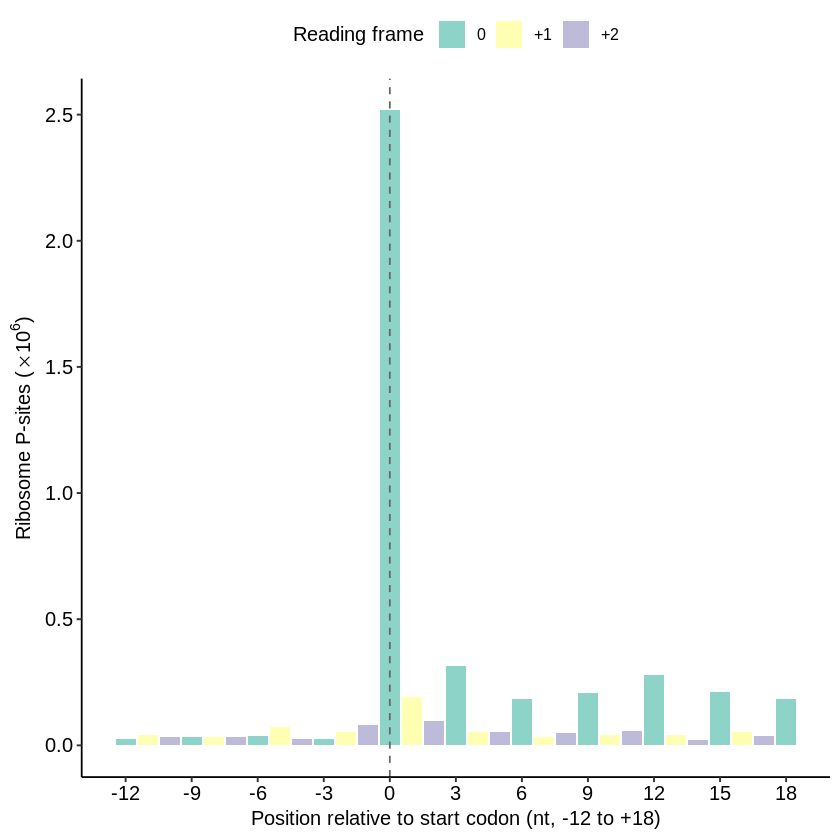

In [70]:
plot_start_distr_sum("/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/qual_assess/ribotish/*.RPF_start_distr_file.txt",
                    "../figures/qual_assess/rpf_start_distribution.pdf")